# Figure 3: interannual variability of T,S

In [1]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import PathPatch
import xarray as xr
import numpy as np
import matplotlib as mpl
from matplotlib import gridspec
import matplotlib.path as mpath

import matplotlib.colors as mcolors
import intake 
from matplotlib import ticker, cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter,
                                LatitudeLocator, LongitudeLocator)
import matplotlib.ticker as mticker
import cmocean.cm as cmocean
import cmcrameri
import dask.distributed as dask

import sys
sys.path.append("/g/data/x77/ps7863/python_scripts/AABW_variability/")
import helper_funcs as helper

In [2]:
client = dask.Client(threads_per_worker = 1)
client


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 34361 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/34361/status,
Dashboard: /proxy/34361/status,Workers: 24
Total threads: 24,Total memory: 95.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39341,Workers: 0
Dashboard: /proxy/34361/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:35305,Total threads: 1
Dashboard: /proxy/36033/status,Memory: 3.96 GiB
Nanny: tcp://127.0.0.1:37453,


In [3]:
catalog = intake.cat.access_nri

In [4]:
figdir = '/g/data/x77/ps7863/figures/AABW_variability/bottom_500m/'
iaf_cycle3 = '01deg_jra55v140_iaf_cycle3'
expt = '01deg_jra55v140_iaf_cycle3_antarctic_tracers'

In [5]:
# lon_slice = slice(80-360, 190-360)
lat_slice = slice(-82, -55)

degree =  u'\N{DEGREE SIGN}'

In [6]:
datastore = catalog[iaf_cycle3].search(variable='ht')
datastore = datastore.search(path=datastore.df.loc[0,'path'])
dataset = datastore.to_dask(xarray_open_kwargs = {"decode_timedelta" : True })
dataset = dataset.squeeze()

ht = dataset['ht']
land = xr.where(np.isnan(ht.rename('land')), 1, np.nan)

In [7]:
shelf_mask = ht > 1000
shelf_mask = shelf_mask.astype(bool)
masked_shelf = shelf_mask.where(shelf_mask==0, np.nan)
shelf_mask = shelf_mask.where(shelf_mask==1, np.nan)
shelf_mask

<xarray.DataArray 'ht' (yt_ocean: 2700, xt_ocean: 3600)> Size: 78MB
dask.array<where, shape=(2700, 3600), dtype=float64, chunksize=(2700, 3600), chunktype=numpy.ndarray>
Coordinates:
  * yt_ocean  (yt_ocean) float64 22kB -81.11 -81.07 -81.02 ... 89.89 89.94 89.98
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
    time      datetime64[ns] 8B 1900-01-01
Attributes:
    long_name:      ocean depth on t-cells
    units:          m
    valid_range:    [-1.e+09  1.e+09]
    cell_methods:   time: point
    standard_name:  sea_floor_depth_below_geoid

In [8]:
xt_ocean = ht.xt_ocean
yt_ocean = ht.yt_ocean

In [9]:
X, Y = np.meshgrid(xt_ocean, yt_ocean)
X = xr.DataArray(X, coords=[yt_ocean, xt_ocean], dims=['yt_ocean', 'xt_ocean'])
Y = xr.DataArray(Y, coords=[yt_ocean, xt_ocean], dims=['yt_ocean', 'xt_ocean'])

In [10]:
def make_boundary_path(longitudes, latitudes):
    """
    Return a path around boundary to create a sector map, then cut it out given
    longitudes and latitudes.
    """

    boundary_path = np.array([longitudes[-1, :], latitudes[-1, :]])
    boundary_path = np.append(
        boundary_path, np.array([longitudes[::-1, -1], latitudes[::-1, -1]]), axis=1
    )
    boundary_path = np.append(
        boundary_path, np.array([longitudes[1, ::-1], latitudes[1, ::-1]]), axis=1
    )
    boundary_path = np.append(
        boundary_path, np.array([longitudes[:, 1], latitudes[:, 1]]), axis=1
    )
    boundary_path = mpath.Path(np.swapaxes(boundary_path, 0, 1))

    return boundary_path

In [11]:
# To plot 1000-m contour
contour_file = np.load('/g/data/ik11/grids/Antarctic_slope_contour_1000m.npz')
shelf = contour_file['contour_masked_above']
yt_ocean = contour_file['yt_ocean']
xt_ocean = contour_file['xt_ocean']
# Mask values that are non-zero
shelf[np.where(shelf!=0)] = np.nan
shelf = shelf+1
shelf = np.nan_to_num(shelf)
shelf = xr.DataArray(shelf, coords = [('yt_ocean', yt_ocean), ('xt_ocean', xt_ocean)])

In [12]:
land_50m = cfeature.NaturalEarthFeature(
    "physical", "land", "50m", edgecolor="black", facecolor="grey", linewidth=0.5
)

In [13]:
first_year = 1958
last_year = 2018
start_time = f'01-01-{first_year}'
end_time = f'31-12-{last_year}'
time_slice = slice(start_time, end_time)

In [14]:
# Absolute salinity 
salt_iav = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/salt_abs_std.nc')
salt_iav = salt_iav['salt_abs_std']
salt_iav = salt_iav.load()

temp_iav = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/temp_std.nc')
temp_iav = temp_iav['temp_iav_std']
temp_iav = temp_iav.load()

In [15]:
bathymetry = ht.load()
land =xr.where(np.isnan(bathymetry.rename("land")), 1, np.nan)
# land = land.assign_coords({"geolon_t": geolon_t, "geolat_t": geolat_t})

In [16]:
outpath = '/g/data/x77/ps7863/data/swmt/'

In [17]:
def get_SWMT(outpath):
    # net_transformation = xr.open_dataset(outpath + '/SWMT_' + time_bounds + '_adelie.nc', chunks={'isopycnal_bins':1})
    # net_transformation = net_transformation.surface_water_mass_transformation
    heat_transformation = xr.open_mfdataset(outpath + 'binned_heat_transformation_mom5_*.nc', chunks={'isopycnal_bins':1},combine='nested', concat_dim='time')
    heat_transformation = heat_transformation.heat_transformation
    salt_transformation = xr.open_mfdataset(outpath + '/binned_salt_transformation_mom5_*.nc', chunks={'isopycnal_bins':1},combine='nested', concat_dim='time')
    salt_transformation = salt_transformation.salt_transformation
    return heat_transformation, salt_transformation # net_transformation 

In [18]:
swmt_heat, swmt_salt = get_SWMT(outpath)
swmt_net = swmt_heat + swmt_salt

In [19]:
prydz_mask = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/prydz_tracer_mask.nc')
adelie_mask = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/adelie_tracer_mask.nc') 
weddell_mask = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/weddell_tracer_mask.nc')  
ross_mask = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/ross_tracer_mask.nc')   
prydz_mask = prydz_mask['Prydz tracer mask']
adelie_mask = adelie_mask['Adelie tracer mask']
ross_mask = ross_mask['Ross tracer mask'] 
weddell_mask = weddell_mask['Weddell tracer mask']

In [20]:
weddell_transformation_density = 37.355

weddell_subduction_plot = swmt_net.sel(isopycnal_bins = weddell_transformation_density, method='nearest') * 1e4
weddell_swmt_xt = weddell_subduction_plot.xt_ocean
weddell_swmt_yt = weddell_subduction_plot.yt_ocean

In [21]:
ross_transformation_density = 37.39
ross_subduction_plot = swmt_net.sel(isopycnal_bins=ross_transformation_density, method='nearest') * 1e4
# ross_subduction_plot = ross_subduction_plot * ross_mask
ross_subduction_plot = ross_subduction_plot.sortby(ross_subduction_plot.xt_ocean)

In [22]:
eastAA_transformation_density = 37.27
eastAA_subduction_plot = swmt_net.sel(isopycnal_bins=eastAA_transformation_density, method='nearest') * 1e4
eastAA_subduction_plot = eastAA_subduction_plot.sortby(eastAA_subduction_plot.xt_ocean)


In [23]:
# Function to create individual subplots
def create_subplot(gs_position, projection, minlon, maxlon, minlat, maxlat):

    ax = fig.add_subplot(gs[gs_position], projection=projection)
    ax.set_extent([minlon, maxlon, minlat, maxlat], crs=ccrs.PlateCarree())
    
    # Select data for the current subplot
    lons = X.sel({"xt_ocean": slice(minlon, maxlon), "yt_ocean": slice(minlat, maxlat)})
    lats = Y.sel({"xt_ocean": slice(minlon, maxlon), "yt_ocean": slice(minlat, maxlat)})
    
    # Generate boundary path
    boundary_path = make_boundary_path(lons, lats)
    ax.set_boundary(boundary_path, transform=ccrs.PlateCarree())  
    ax.add_patch(PathPatch(boundary_path, transform=ccrs.PlateCarree(), fc='none', ec='black', lw=1.5))
    ax.spines['geo'].set_visible(True) 
    # gl = ax.gridlines(draw_labels=True, dms=True, linestyle='--', color='grey', x_inline=False, y_inline=False)
    # gl.xformatter = LongitudeFormatter()
    # gl.yformatter = LatitudeFormatter()
    # gl.ylocator = mticker.FixedLocator([-75, -70, -65, -60, -55, -50])
    # gl.xlocator = mticker.FixedLocator([-160, -140, -120, -100, -80, -60, -40, -20, 0, 20, 40, 60, 80, 100, 120, 140, 160, 180])
    # gl.xlabels_bottom = False 
    # gl.ylabels_left = False
    # gl.xlabel_style = {'size': 8}
    # gl.ylabel_style = {'size': 8}
    return ax


# Define first projection parameters
midlon1 = 150-360 # 135
maxlon1 = midlon1 + 70
minlon1 = midlon1 - 70
minlat1 = -80
maxlat1 = -50
midlat1 = (minlat1 + maxlat1) / 2

projection1 = ccrs.Stereographic(central_longitude=midlon1, central_latitude=midlat1)

# Define second projection parameters
midlon2 = 5
maxlon2 = midlon2 + 75
minlon2 = midlon2 - 75
minlat2 = -80
maxlat2 = -50
midlat2 = (minlat2 + maxlat2) / 2

projection2 = ccrs.Stereographic(central_longitude=midlon2, central_latitude=midlat2)



In [24]:
temp_iav.load()
salt_iav.load()

<xarray.DataArray 'salt_abs_std' (yt_ocean: 666, xt_ocean: 3600)> Size: 19MB
array([[       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       ...,
       [0.00218859, 0.00219596, 0.00218034, ..., 0.00214767, 0.00212738,
        0.00213784],
       [0.00224763, 0.00220308, 0.00218981, ..., 0.00215219, 0.00219708,
        0.00220273],
       [0.00220165, 0.00215657, 0.00219187, ..., 0.00220818, 0.00225187,
        0.00222621]])
Coordinates:
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
  * yt_ocean  (yt_ocean) float64 5kB -81.11 -81.07 -81.02 ... -50.09 -50.03

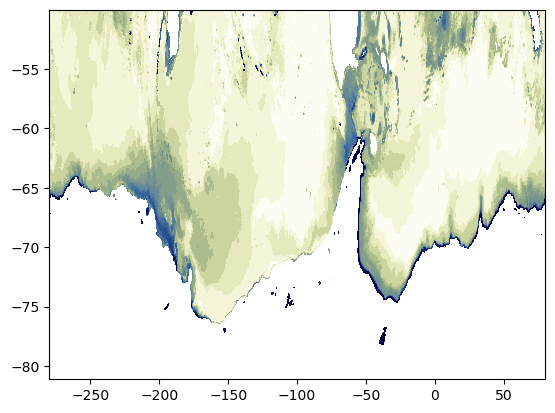

In [29]:
levels_salt = np.arange(0, 0.042, 0.0025)
plt.contourf(salt_iav.xt_ocean, salt_iav.yt_ocean, salt_iav*2, 
                levels=levels_salt,
                cmap=cmcrameri.cm.davos_r,
                extend='max')

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 13.97 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 13.97 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


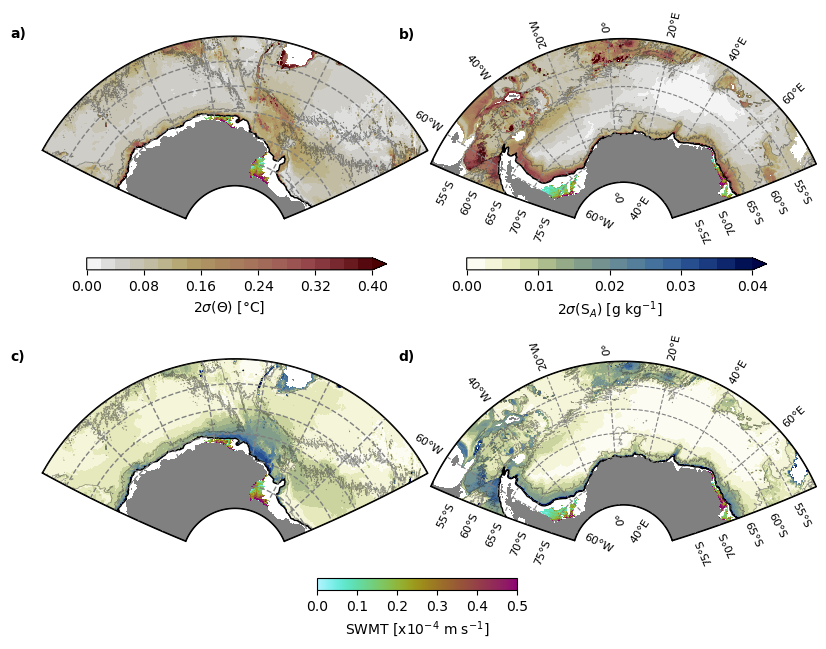

In [24]:
cmap_salt = cmcrameri.cm.davos_r
fontsize=10
levels_salt = np.arange(0, 0.0425, 0.0025)

# cmap_temp = cmcrameri.cm.lipari_r
cmap_temp = cmcrameri.cm.bilbao_r
levels_temp = np.arange(0, 0.42, 0.02)

cmap_smwt = cmcrameri.cm.hawaii_r
norm_swmt = mcolors.TwoSlopeNorm(vmin=0, vcenter=0.25, vmax=0.5)

# Create figure and GridSpec layout (2x2)
fig = plt.figure(figsize=(10, 8)) #, constrained_layout=True)
gs = gridspec.GridSpec(2, 2, figure=fig, wspace=0.005, hspace=0.1)  # Adjust subplot spacing



# First subplot (Projection 1) 
ax1 = create_subplot((0, 0), projection1, minlon1, maxlon1, minlat1, maxlat1)
cf1=plt.contourf(temp_iav.xt_ocean, temp_iav.yt_ocean, temp_iav*2,
                levels=levels_temp,
                transform=ccrs.PlateCarree(),
                cmap=cmap_temp,
                extend='max', 
                zorder=0)



# Second subplot (Projection 2)
ax2 = create_subplot((0, 1), projection2, minlon2, maxlon2, minlat2, maxlat2)
plt.contourf(temp_iav.xt_ocean, temp_iav.yt_ocean, temp_iav*2,
                levels=levels_temp,
                transform=ccrs.PlateCarree(),
                cmap=cmap_temp,
                extend='max', 
                zorder=0)

# Third subplot (Projection 1)
ax3 = create_subplot((1, 0), projection1, minlon1, maxlon1, minlat1, maxlat1)
cf2=plt.contourf(salt_iav.xt_ocean, salt_iav.yt_ocean, salt_iav*2,
                levels=levels_salt,
                transform=ccrs.PlateCarree(),
                cmap=cmap_salt,
                extend='max', 
                zorder=0)

# Fourth subplot (Projection 2)
ax4 = create_subplot((1, 1), projection2, minlon2, maxlon2, minlat2, maxlat2)
plt.contourf(salt_iav.xt_ocean, salt_iav.yt_ocean, salt_iav*2, 
                levels=levels_salt,
                transform=ccrs.PlateCarree(),
                cmap=cmap_salt,
                extend='max', 
                zorder=0)


for ax in [ax1, ax2, ax3, ax4]:
    # 3500 isobath
    ax.contour(ht.xt_ocean, ht.yt_ocean, ht,
                levels=[3500],
                colors='0.2',
                linewidths=[0.5, 2, 0.5, 0.5],
                alpha=0.5,
                transform=ccrs.PlateCarree())
    # SHELFBREAK
    ax.contour(shelf.xt_ocean, shelf.yt_ocean,shelf,
                [0.5],
                colors = 'k',
                linewidths = 1,
                transform=ccrs.PlateCarree())
    # SHELF FILLED CONTOUR
    ax.contourf(shelf.xt_ocean, shelf.yt_ocean, shelf,
                [0.5, 1],
                transform=ccrs.PlateCarree(),
                colors='white',
                zorder=0.1
               )
    # LAND
    ax.contourf(land.xt_ocean, land.yt_ocean, land,
             transform=ccrs.PlateCarree(),
             colors='grey', 
                zorder=0.2
            )



lats = [-50, -55, -60, -65, -70, -75]
lons = [100, 120, 140, 160, 180, 200]

for ax in [ax1, ax3]:
    for lat in lats:
        ax.plot(np.arange(-280, -140, 0.01), np.full_like(np.arange(-280, -140, 0.01), lat), transform=ccrs.PlateCarree(), linestyle='--', color='grey', linewidth=1, zorder=2)
    for lon in lons:
        ax.plot(np.full_like(np.arange(-76, -50, 0.01), lon), np.arange(-76, -50, 0.01), transform=ccrs.PlateCarree(), linestyle='--', color='grey', linewidth=1, zorder=2)
    pc=(ross_subduction_plot*ross_mask).mean('time').plot.pcolormesh(
            ax=ax,
            norm=norm_swmt,
            transform=ccrs.PlateCarree(), 
            cmap=cmap_smwt, 
            add_colorbar=False, 
            zorder=0.3
            )
    (eastAA_subduction_plot*adelie_mask).mean('time').plot.pcolormesh( 
            ax=ax,
            norm=norm_swmt,
            transform=ccrs.PlateCarree(),
            cmap=cmap_smwt,
            add_colorbar=False, 
            zorder=0.3
            )

for ax in [ax2, ax4]:
    gl = ax.gridlines(draw_labels=True, dms=True, linestyle='--', color='grey', x_inline=False, y_inline=False)
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()
    gl.ylocator = mticker.FixedLocator([-75, -70, -65, -60, -55, -50])
    gl.xlocator = mticker.FixedLocator([-60, -40, -20, 0, 20, 40, 60, 80])
    gl.labels_bottom = False 
    gl.labels_left = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    (weddell_subduction_plot*weddell_mask).mean('time').plot.pcolormesh(
            ax=ax,
            norm=norm_swmt,
            transform=ccrs.PlateCarree(), 
            cmap=cmap_smwt,
            add_colorbar=False, 
            zorder=0.3
            )

    (eastAA_subduction_plot*prydz_mask).mean('time').plot.pcolormesh(
                ax=ax,
                norm=norm_swmt,
                transform=ccrs.PlateCarree(),
                cmap=cmap_smwt,
                add_colorbar=False, 
                zorder=0.3
                )
    
cbar_ax1 = fig.add_axes([0.17, 0.52, 0.3, 0.015])  # [left, bottom, width, height]
cbar_ax2 = fig.add_axes([0.55, 0.52, 0.3, 0.015])
cbar_ax3 = fig.add_axes([0.4, 0.12, 0.2, 0.015])

cbar1 = plt.colorbar(cf1, cax=cbar_ax1,
                     orientation='horizontal',
                     spacing='proportional',
                     ticks=[0, 0.08, 0.16, 0.24, 0.32, 0.4],
                     location='bottom'
                    )

cbar2 = plt.colorbar(cf2, cax=cbar_ax2, 
                     orientation='horizontal',
                     spacing='proportional',
                     ticks=[0, 0.01, 0.02, 0.03, 0.04, 0.05],
                     location='bottom'
                    )

cbar3 = plt.colorbar(pc, cax=cbar_ax3,
                     orientation='horizontal',
                     spacing='proportional',
                     ticks=[0, 0.1, 0.2, 0.3, 0.4, 0.5],
                     location='bottom'
                    )
cbar1.set_label(r'2$\sigma$($\Theta$) ' + f'[{degree}C]', fontsize=10)
cbar2.set_label(r'2$\sigma$(S$_A$) [g kg$^{-1}$]', fontsize=10)
cbar3.set_label(r'SWMT [x10$^{-4}$ m s$^{-1}$]', fontsize=10)
for ax, label in zip([ax1, ax2, ax3, ax4], ['a)', 'b)', 'c)', 'd)']):
    ax.annotate(
        label,
        xy=(-0.1, 1.1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize=10, verticalalignment='top', fontfamily='sans-serif',
        fontweight='semibold')
    ax.set_title('')
# plt.tight_layout()


plt.savefig(f'{figdir}/Fig3_TS_iav.png', dpi=300, bbox_inches='tight')
